In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path("..").resolve() / "src"))
figures_dir = Path("..") / "figures"
figures_dir.mkdir(exist_ok=True)


from quant_framework.interest_rate.CIR import CIRModel
from quant_framework.interest_rate.vasicek import VasicekModel

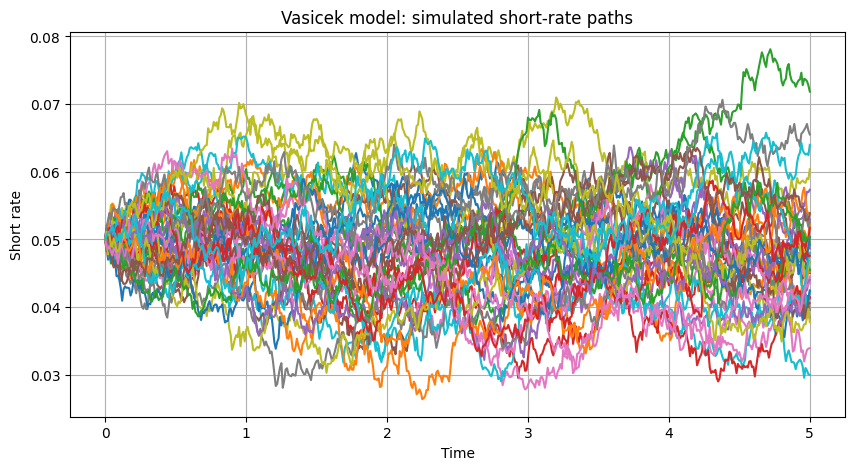

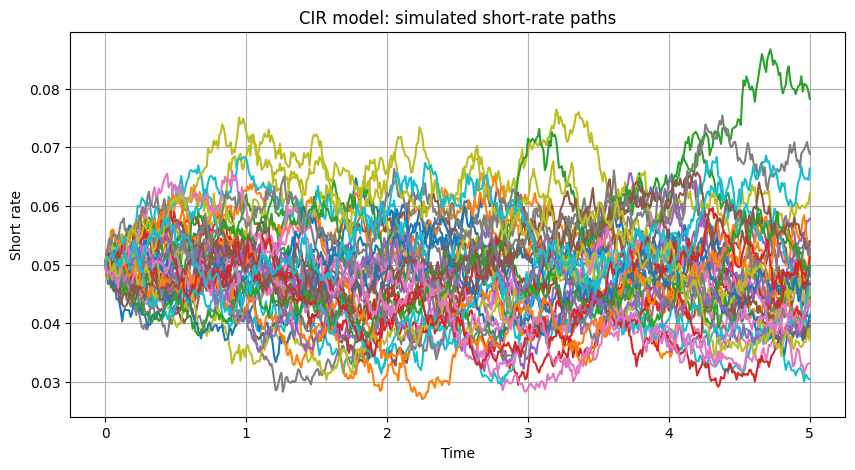

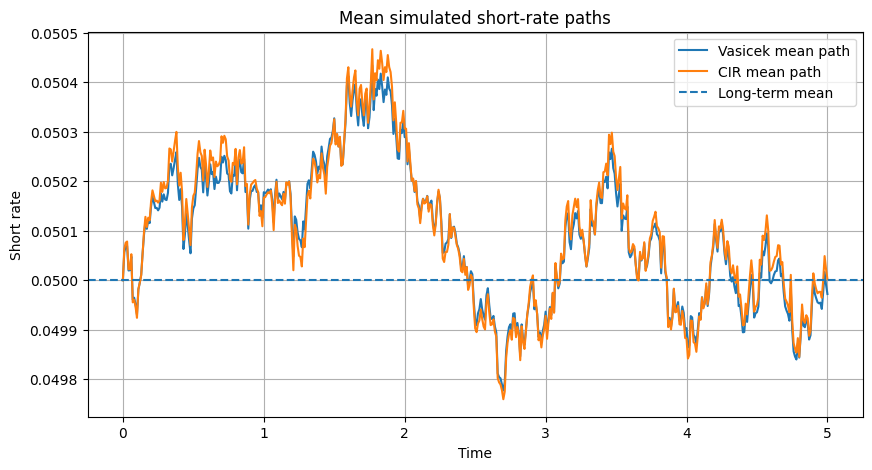

Minimum Vasicek rate: 0.0162
Minimum CIR rate: 0.0199


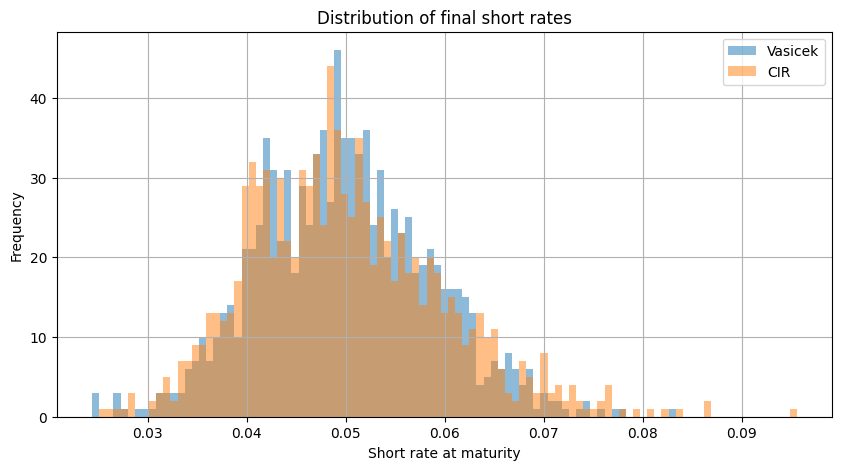

In [4]:
maturity = 5.0
num_steps = 500
num_paths = 1000
seed = 35

time_grid = np.linspace(0.0, maturity, num_steps + 1)

vasicek = VasicekModel(
    initial_rate=0.05,
    volatility=0.01,
    mean_level=0.05,
    mean_revert_speed=0.7,
)

cir = CIRModel(
    initial_rate=0.05,
    volatility=0.05,
    mean_level=0.05,
    mean_revert_speed=0.7,
)

vasicek_paths = vasicek.simulate_paths(
    maturity=maturity,
    num_steps=num_steps,
    num_paths=num_paths,
    seed=seed,
)

cir_paths = cir.simulate_paths(
    maturity=maturity,
    num_steps=num_steps,
    num_paths=num_paths,
    seed=seed,
)

plt.figure(figsize=(10, 5))

for i in range(40):
    plt.plot(time_grid, vasicek_paths[i])

plt.xlabel("Time")
plt.ylabel("Short rate")
plt.title("Vasicek model: simulated short-rate paths")
plt.grid(True)

plt.savefig(figures_dir / "vasicek_paths.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))

for i in range(40):
    plt.plot(time_grid, cir_paths[i])

plt.xlabel("Time")
plt.ylabel("Short rate")
plt.title("CIR model: simulated short-rate paths")
plt.grid(True)

plt.savefig(figures_dir / "cir_paths.png", dpi=300, bbox_inches="tight")
plt.show()

vasicek_mean = vasicek_paths.mean(axis=0)
cir_mean = cir_paths.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(time_grid, vasicek_mean, label="Vasicek mean path")
plt.plot(time_grid, cir_mean, label="CIR mean path")
plt.axhline(0.05, linestyle="--", label="Long-term mean")

plt.xlabel("Time")
plt.ylabel("Short rate")
plt.title("Mean simulated short-rate paths")
plt.legend()
plt.grid(True)

plt.savefig(figures_dir / "mean_paths_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

vasicek_min = vasicek_paths.min()
cir_min = cir_paths.min()

print(f"Minimum Vasicek rate: {vasicek_min:.4f}")
print(f"Minimum CIR rate: {cir_min:.4f}")

plt.figure(figsize=(10, 5))

all_rates = np.concatenate([
    vasicek_paths[:, -1],
    cir_paths[:, -1],
])

bins = np.linspace(all_rates.min(), all_rates.max(), 100)

plt.hist(vasicek_paths[:, -1], bins=bins, alpha=0.5, label="Vasicek")
plt.hist(cir_paths[:, -1], bins=bins, alpha=0.5, label="CIR")

plt.xlabel("Short rate at maturity")
plt.ylabel("Frequency")
plt.title("Distribution of final short rates")
plt.legend()
plt.grid(True)

plt.savefig(figures_dir / "final_rate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

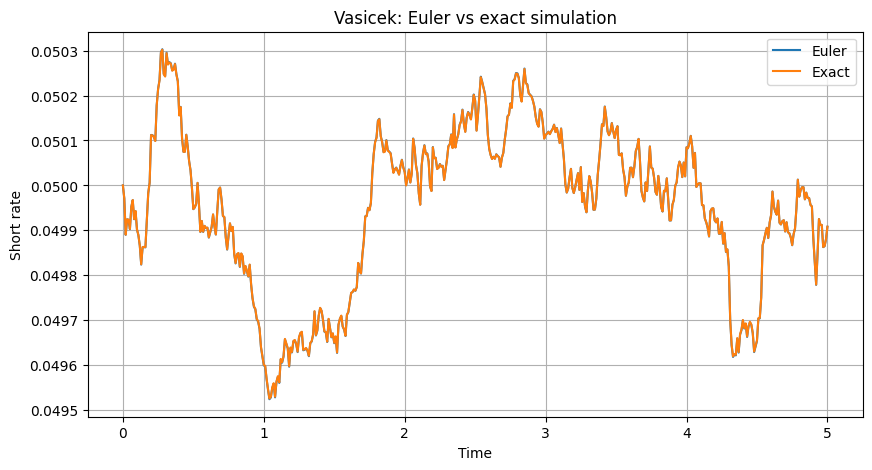

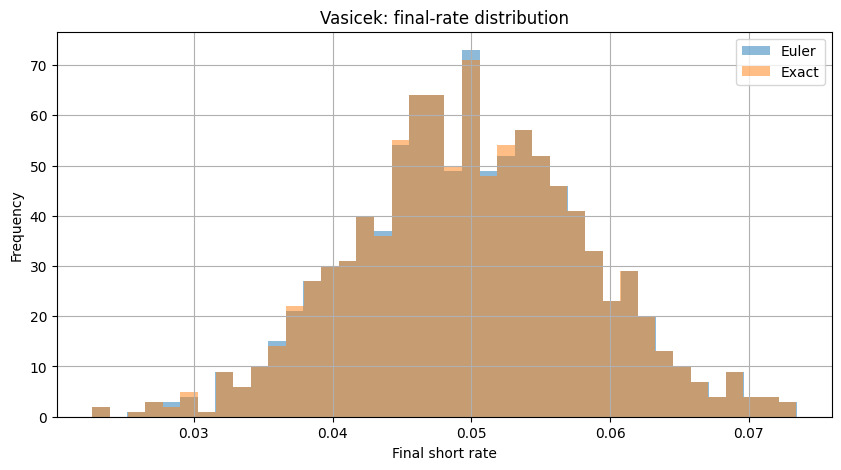

Euler final mean: 0.04990790140440729
Exact final mean: 0.04990803864871844
Absolute difference: 1.3724431115191837e-07


In [6]:
euler_paths = vasicek.simulate_paths(
    maturity=maturity,
    num_steps=num_steps,
    num_paths=num_paths,
    seed=42,
    method="euler",
)

exact_paths = vasicek.simulate_paths(
    maturity=maturity,
    num_steps=num_steps,
    num_paths=num_paths,
    seed=42,
    method="exact",
)

euler_mean = euler_paths.mean(axis=0)
exact_mean = exact_paths.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, euler_mean, label="Euler")
plt.plot(time_grid, exact_mean, label="Exact")

plt.xlabel("Time")
plt.ylabel("Short rate")
plt.title("Vasicek: Euler vs exact simulation")
plt.legend()
plt.grid(True)

plt.savefig(figures_dir / "vasicek_euler_vs_exact_mean.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))

plt.hist(euler_paths[:, -1], bins=40, alpha=0.5, label="Euler")
plt.hist(exact_paths[:, -1], bins=40, alpha=0.5, label="Exact")

plt.xlabel("Final short rate")
plt.ylabel("Freqчёuency")
plt.title("Vasicek: final-rate distribution")
plt.legend()
plt.grid(True)

plt.savefig(figures_dir / "vasicek_euler_vs_exact_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Euler final mean:", euler_paths[:, -1].mean())
print("Exact final mean:", exact_paths[:, -1].mean())
print("Absolute difference:", abs(euler_paths[:, -1].mean() - exact_paths[:, -1].mean()))